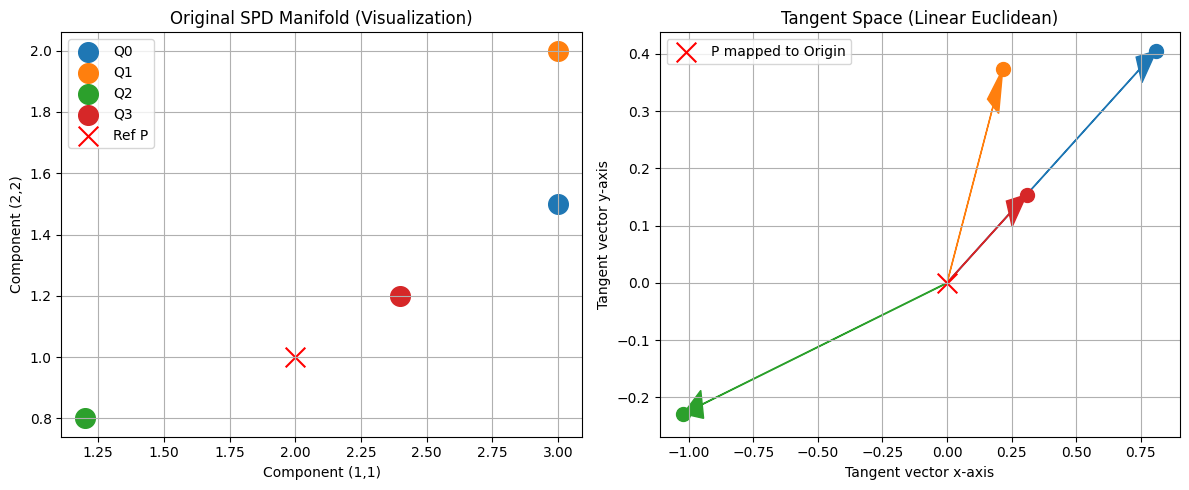

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def matrix_log(M):
    """計算矩陣對數 (僅使用 numpy 特徵分解)"""
    evals, evecs = np.linalg.eigh(M)
    return evecs @ np.diag(np.log(evals)) @ evecs.T

def matrix_sqrt(M):
    """計算矩陣平方根"""
    evals, evecs = np.linalg.eigh(M)
    return evecs @ np.diag(np.sqrt(evals)) @ evecs.T

def matrix_inv_sqrt(M):
    """計算矩陣負平方根"""
    evals, evecs = np.linalg.eigh(M)
    return evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T

def upper(K):
    """模擬 upper() 操作：提取上三角並向量化"""
    n = K.shape[0]
    # 提取上三角索引
    idx = np.triu_indices(n)
    vec = K[idx].copy()

    # 為了保持範數一致，非對角線元素乘以 sqrt(2)
    # (這在很多 paper 的 upper 實作中是標準做法)
    diag_mask = np.eye(n, dtype=bool)[idx]
    vec[~diag_mask] *= np.sqrt(2)
    return vec

# 1. 定義參考點 P 與多個數據點 Q_i (2x2 SPD 矩陣)
P = np.array([[2, 0.5], [0.5, 1]]) # 切點
Qs = [
    P * 1.5,                                     # 縮放變換
    np.array([[3, -1], [-1, 2]]),                # 不同方向的變換
    np.array([[1.2, 0.3], [0.3, 0.8]]),          # 縮小變換
    P @ np.array([[0, 1], [1, 0]]) @ P.T / 5 + P # 擾動變換
]

# 2. 執行 Tangent Space Mapping
P_half = matrix_sqrt(P)
P_inv_half = matrix_inv_sqrt(P)

tangent_vectors = []
Ks = []
for Q in Qs:
    # 套用公式: K = P^0.5 * log(P^-0.5 * Q * P^-0.5) * P^0.5
    inner = P_inv_half @ Q @ P_inv_half
    K = P_half @ matrix_log(inner) @ P_half
    K_upper = upper(K)
    Ks.append(K_upper)
    # 由於 K 是 2x2 對稱矩陣，提取獨立分量 (k11, k22, k12) 進行 2D 繪圖
    tangent_vectors.append([K[0,0], K[1,1]])

# 3. 繪圖與比較
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 左圖：原始 SPD 空間 (以橢圓形狀模擬矩陣特性)
ax1.set_title("Original SPD Manifold (Visualization)")
for i, Q in enumerate(Qs):
    ax1.scatter(Q[0,0], Q[1,1], s=200, label=f'Q{i}')
ax1.scatter(P[0,0], P[1,1], c='red', marker='x', s=200, label='Ref P')
ax1.set_xlabel("Component (1,1)")
ax1.set_ylabel("Component (2,2)")
ax1.grid(True)
ax1.legend()

# 右圖：轉換後的切空間 (線性向量空間)
ax2.set_title("Tangent Space (Linear Euclidean)")
for i, v in enumerate(tangent_vectors):
    ax2.arrow(0, 0, v[0], v[1], head_width=0.05, length_includes_head=True, color=f'C{i}')
    ax2.scatter(v[0], v[1], s=100)
ax2.scatter(0, 0, c='red', marker='x', s=200, label='P mapped to Origin')
ax2.set_xlabel("Tangent vector x-axis")
ax2.set_ylabel("Tangent vector y-axis")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def upper_vector(K):
    """模擬 upper() 操作：提取上三角並向量化"""
    n = K.shape[0]
    # 提取上三角索引
    idx = np.triu_indices(n)
    vec = K[idx].copy()

    # 為了保持範數一致，非對角線元素乘以 sqrt(2)
    # (這在很多 paper 的 upper 實作中是標準做法)
    diag_mask = np.eye(n, dtype=bool)[idx]
    vec[~diag_mask] *= np.sqrt(2)
    return vec

# 1. 產生一個 2x2 對稱矩陣 K (切空間中的點)
K = np.array([[1.5, 0.8],
              [0.8, -0.5]])

# 2. 執行 upper() 轉換
z = upper_vector(K)

print("切空間矩陣 K:\n", K)
print(f"\n矩陣元素總數: {K.size}")
print(f"轉換後的特徵向量 z: {z}")
print(f"向量長度: {len(z)} (符合 n(n+1)/2 = 2*3/2 = 3)")

# 3. 驗證: 矩陣的範數是否等於向量的範數
norm_K = np.linalg.norm(K)
norm_z = np.linalg.norm(z)
print(f"\n矩陣範數: {norm_K:.4f}")
print(f"向量範數: {norm_z:.4f}")
print(f"兩者是否相等? {np.allclose(norm_K, norm_z)}")

切空間矩陣 K:
 [[ 1.5  0.8]
 [ 0.8 -0.5]]

矩陣元素總數: 4
轉換後的特徵向量 z: [ 1.5         1.13137085 -0.5       ]
向量長度: 3 (符合 n(n+1)/2 = 2*3/2 = 3)

矩陣範數: 1.9442
向量範數: 1.9442
兩者是否相等? True


In [11]:
z

array([ 1.5       ,  1.13137085, -0.5       ])

In [12]:
Q

array([[2.4 , 0.95],
       [0.95, 1.2 ]])

In [13]:
Qs

[array([[3.  , 0.75],
        [0.75, 1.5 ]]),
 array([[ 3, -1],
        [-1,  2]]),
 array([[1.2, 0.3],
        [0.3, 0.8]]),
 array([[2.4 , 0.95],
        [0.95, 1.2 ]])]